# 06 — Environment (MDP)

**Input:** fitted BKT parameters, the simulated student, the cluster model
**Output:** `eats/simulator/interventions.py` and `eats/simulator/env.py` (a Gymnasium environment)

| | |
|---|---|
| **State** | 7 values: accuracy, response time, hint rate, one-hot error cluster |
| **Actions** | 5: lower / maintain / raise difficulty, give a hint, recommend revision |
| **Reward** | mastery gain, minus a small cost for hinting, plus a term for moving to a less severe error cluster |
| **γ** | 0.95 |
| **Episode** | one student, 20 steps (the mean sequence length in the data) |

### Design notes

1. **The agent sees the observable features; the reward uses mastery.** Observed accuracy can be raised by making the work easier, so rewarding it would favour always lowering difficulty. Section 6.4 checks this.
2. **Hints help learning but are recorded as incorrect.** In the simulator a hint raises the learning rate, but it shows up as a wrong answer.
3. **The hint cost is charged on the action.** Penalising the observed hint rate would overlap with accuracy, since hinted items are always incorrect.

In [10]:
import importlib
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EATS = Path(r"C:\Users\vedac\Desktop\EATS")
sys.path.insert(0, str(EATS))
PROCESSED = EATS / "data" / "processed"
FIGURES = EATS / "results" / "figures"
MODELS = EATS / "models"

pd.set_option("display.width", 170)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 9,
                     "axes.grid": True, "grid.alpha": 0.25})
BLUE, RED, GREY, GREEN = "#4C72B0", "#C44E52", "#7F7F7F", "#55A868"
SEED = 42

from eats.simulator.bkt import BKTParams
from eats.simulator.student import EmpiricalObservables

raw = pd.read_parquet(PROCESSED / "interactions_clean.parquet")
bundle = joblib.load(MODELS / "bkt_params.joblib")
PARAMS = {d["skill"]: BKTParams(**d) for d in bundle["params"]}
SKILLS = bundle["skills"]

cluster_model = joblib.load(MODELS / "error_clusters.joblib")

# Per-skill normalisation constants for response time, same as notebook 04.
RT_STATS = {}
for s in SKILLS:
    v = raw.loc[raw["skill"] == s, "ms_first_response"]
    clip = np.percentile(v, cluster_model["clip_percentile"])
    lg = np.log1p(np.minimum(v, clip) / 1000)
    RT_STATS[s] = {"clip": float(clip), "mean": float(lg.mean()), "std": float(lg.std())}

print(f"{len(PARAMS)} skills loaded")
for s, p in PARAMS.items():
    print(f"  {s[:34]:<36} L0={p.L0:.3f} T={p.T:.3f} G={p.G:.3f} S={p.S:.3f}")

5 skills loaded
  Addition and Subtraction Fractions   L0=0.700 T=0.060 G=0.300 S=0.222
  Equation Solving More Than Two Ste   L0=0.445 T=0.081 G=0.207 S=0.300
  Equation Solving Two or Fewer Step   L0=0.800 T=0.043 G=0.300 S=0.214
  Division Fractions                   L0=0.624 T=0.105 G=0.269 S=0.234
  Multiplication Fractions             L0=0.594 T=0.112 G=0.300 S=0.233


## 6.1 Intervention effects

The data has no record of a tutor choosing between these five actions, so their effects can't be estimated from it. They are assumptions, kept in one module and printed as a table below. They are based on:

- **Desirable difficulties** (Bjork & Bjork, 2011): harder work lowers immediate accuracy but can improve learning. So raising difficulty lowers the chance of a correct answer and raises the learning rate; lowering does the opposite.
- **Scaffolding** (Wood, Bruner & Ross, 1976): support helps learning, so hints raise the learning rate, with a cost.
- **Prerequisites:** revising a prerequisite helps later learning of the dependent skill.

In [11]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/simulator/interventions.py
"""What each intervention does to the BKT dynamics.

EVERY assumption in the simulator lives here. Nothing elsewhere modifies learning
behaviour. That is deliberate: it makes the assumptions auditable, printable as a
table, and variable for a sensitivity analysis.

BKT itself is fitted from data. These multipliers are not - they are grounded in
pedagogical literature and must be reported as assumptions.
"""

from __future__ import annotations

ACTIONS = [
    "lower_difficulty",
    "maintain_difficulty",
    "raise_difficulty",
    "provide_hint",
    "recommend_revision",
]
N_ACTIONS = len(ACTIONS)

DIFFICULTY_LEVELS = ["easy", "medium", "hard"]

# --- Difficulty ------------------------------------------------------------
# Desirable difficulties (Bjork & Bjork, 2011): easier material raises immediate
# success but slows real learning; harder material does the opposite.
#
#   guess_mult : multiplies G - chance of success without knowing the skill
#   learn_mult : multiplies T - chance of learning at this opportunity
DIFFICULTY_EFFECTS = {
    0: {"guess_mult": 1.60, "learn_mult": 0.70, "label": "easy"},
    1: {"guess_mult": 1.00, "learn_mult": 1.00, "label": "medium"},
    2: {"guess_mult": 0.60, "learn_mult": 1.30, "label": "hard"},
}

# --- Hint ------------------------------------------------------------------
# Scaffolding (Wood, Bruner & Ross, 1976) raises learning at this opportunity.
# In ASSISTments a hint also forces the item to be recorded as incorrect, so the
# observed signal worsens while the latent state improves.
HINT_LEARN_MULT = 1.45

# --- Revision --------------------------------------------------------------
# Practising the prerequisite instead of the target skill. Costs one opportunity
# on the target, but raises the learn rate afterwards once the prerequisite is
# reasonably secure.
REVISION_LEARN_MULT = 1.50
REVISION_PREREQ_THRESHOLD = 0.50   # prerequisite mastery needed for transfer

# --- Reward weights --------------------------------------------------------
# w_learning : on the change in LATENT mastery, not observed accuracy.
#              Observed accuracy is gameable by lowering difficulty; latent
#              mastery is not.
# w_hint     : a cost charged when the agent CHOOSES to hint. Deliberately not a
#              penalty on observed hint rate - hints force incorrectness, so that
#              would double-count the learning term (see notebook 03).
#              Calibrated BELOW the typical per-step learning gain
#              (T_eff * (1 - mastery), roughly 0.035). A larger cost makes
#              hinting never worthwhile, which would leave one of the five
#              actions dead and the action space smaller than claimed.
# w_misconception : reward for moving to a lower-severity error cluster. Clusters
#              are severity-ordered in notebook 04, which is what makes this meaningful.
REWARD_WEIGHTS = {
    "w_learning": 1.00,
    "w_hint": 0.01,
    "w_misconception": 0.10,
}

# --- Structural constraints (Olukola & Rahimi, 2026) -----------------------
# Reward shaping alone does not prevent degenerate policies; architectural limits
# do. Two are applied:
MAX_CONSECUTIVE_LOWER = 2      # cannot keep making the work easier indefinitely.
                               # NOTE: with three difficulty levels the floor is
                               # reached first and `lower` is masked anyway, so
                               # this rarely binds. Retained for completeness;
                               # report it as redundant rather than as active.
RAISE_REQUIRES_MASTERY = 0.40  # cannot raise difficulty on an unmastered skill

# Prerequisite graph, from the skill selection in notebook 02.
PREREQUISITES = {
    "Multiplication Fractions": "Addition and Subtraction Fractions",
    "Division Fractions": "Multiplication Fractions",
    "Equation Solving More Than Two Steps": "Equation Solving Two or Fewer Steps",
}


def effective_params(params, difficulty, hint=False, revision_boost=False):
    """Apply intervention effects to a skill's fitted BKT parameters.

    Returns (guess, learn_rate) after modulation. Slip and the prior are left
    untouched: nothing in the literature supports an intervention changing how
    often a student who knows a skill slips.
    """
    d = DIFFICULTY_EFFECTS[difficulty]
    g = min(params.G * d["guess_mult"], 0.60)
    t = params.T * d["learn_mult"]
    if hint:
        t *= HINT_LEARN_MULT
    if revision_boost:
        t *= REVISION_LEARN_MULT
    return g, min(t, 0.95)


def assumptions_table():
    """Every assumption, as a dataframe."""
    import pandas as pd

    rows = []
    for level, e in DIFFICULTY_EFFECTS.items():
        rows.append((f"difficulty = {e['label']}", "guess multiplier",
                     e["guess_mult"], "Bjork & Bjork (2011)"))
        rows.append((f"difficulty = {e['label']}", "learn-rate multiplier",
                     e["learn_mult"], "Bjork & Bjork (2011)"))
    rows.append(("provide_hint", "learn-rate multiplier", HINT_LEARN_MULT,
                 "Wood, Bruner & Ross (1976)"))
    rows.append(("recommend_revision", "learn-rate multiplier", REVISION_LEARN_MULT,
                 "prerequisite transfer"))
    rows.append(("recommend_revision", "prerequisite threshold",
                 REVISION_PREREQ_THRESHOLD, "design choice"))
    for k, v in REWARD_WEIGHTS.items():
        rows.append(("reward", k, v, "design choice"))
    rows.append(("constraint", "max consecutive lower_difficulty",
                 MAX_CONSECUTIVE_LOWER, "Olukola & Rahimi (2026)"))
    rows.append(("constraint", "mastery needed to raise difficulty",
                 RAISE_REQUIRES_MASTERY, "Olukola & Rahimi (2026)"))
    return pd.DataFrame(rows, columns=["applies to", "parameter", "value", "grounding"])


Overwriting C:/Users/vedac/Desktop/EATS/eats/simulator/interventions.py


In [12]:
from eats.simulator import interventions as iv

importlib.reload(iv)

table = iv.assumptions_table()
table.to_csv(PROCESSED / "intervention_assumptions.csv", index=False)
print("=== Simulator assumptions ===")
print(table.to_string(index=False))

=== Simulator assumptions ===
         applies to                          parameter  value                  grounding
  difficulty = easy                   guess multiplier   1.60       Bjork & Bjork (2011)
  difficulty = easy              learn-rate multiplier   0.70       Bjork & Bjork (2011)
difficulty = medium                   guess multiplier   1.00       Bjork & Bjork (2011)
difficulty = medium              learn-rate multiplier   1.00       Bjork & Bjork (2011)
  difficulty = hard                   guess multiplier   0.60       Bjork & Bjork (2011)
  difficulty = hard              learn-rate multiplier   1.30       Bjork & Bjork (2011)
       provide_hint              learn-rate multiplier   1.45 Wood, Bruner & Ross (1976)
 recommend_revision              learn-rate multiplier   1.50      prerequisite transfer
 recommend_revision             prerequisite threshold   0.50              design choice
             reward                         w_learning   1.00              desig

### About this table

Every value in this table is assumed, not fitted from data. Keeping them in one place makes it clear what the results depend on, and would make a sensitivity analysis straightforward (not done here).

## 6.2 The environment

`StateBuilder` computes the state features for a simulated student with the same definitions as notebook 04, including the conditional hint rate and the saved cluster model.

`TutoringEnv` is the Gymnasium environment. In `info`, `step` returns mastery, the three reward components, whether the action was masked, and the observation record. Later notebooks use these.

In [13]:
%%writefile C:/Users/vedac/Desktop/EATS/eats/simulator/env.py
"""Gymnasium environment: an RL agent choosing teaching interventions."""

from __future__ import annotations

from collections import deque
from dataclasses import replace

import gymnasium as gym
import numpy as np
from gymnasium import spaces

from eats.simulator import interventions as iv
from eats.simulator.student import BKTStudent

WINDOW = 10          # must match notebook 04
EPISODE_LENGTH = 20  # matches the mean sequence length of 20.0 observed
                     # in the real data (notebook 03). Longer episodes let the
                     # mastery ESTIMATE saturate: true knowledge is monotone
                     # (no forgetting), and while the belief can fall after an
                     # incorrect answer it trends to ~0.95-0.99 in practice, so
                     # every policy reaches ceiling and the conditions become
                     # indistinguishable.


class StateBuilder:
    """Recomputes the four state features from simulated history.

    Uses the notebook 04 definitions exactly, including the conditional hint rate
    (hints per INCORRECT attempt, not per attempt) and the fitted k-means model.
    """

    def __init__(self, cluster_model, rt_stats, window=WINDOW):
        self.km = cluster_model["kmeans"]
        self.scaler = cluster_model["scaler"]
        self.remap = cluster_model["remap"]
        self.n_clusters = len(self.remap)
        # Precomputed for the hot path: assigning a cluster happens once per
        # environment step, and sklearn's predict/transform validation overhead
        # dominates the arithmetic at that scale.
        self._mean = self.scaler.mean_
        self._scale = self.scaler.scale_
        self._centroids = self.km.cluster_centers_
        self.rt_stats = rt_stats
        self.window = window
        self.reset()

    def reset(self):
        self.history = deque(maxlen=self.window)

    def push(self, record):
        self.history.append(record)

    def _response_time(self, skill):
        if not self.history:
            return 0.5
        st = self.rt_stats[skill]
        ms = min(self.history[-1]["ms_first_response"], st["clip"])
        z = (np.log1p(ms / 1000) - st["mean"]) / (st["std"] or 1.0)
        return float((np.clip(z, -3, 3) + 3) / 6)

    def _error_cluster(self):
        if not self.history:
            return 0
        errs = np.array([1.0 - h["correct"] for h in self.history])
        hints = np.array([h["hint_count"] for h in self.history])
        att = np.array([h["attempt_count"] for h in self.history])

        best = run = 0
        for e in errs:
            run = run + 1 if e > 0.5 else 0
            best = max(best, run)

        profile = np.array([errs.mean(), best / self.window, att.mean(),
                            float((hints * errs).mean())])
        # Equivalent to scaler.transform followed by kmeans.predict, without the
        # per-call validation. Standard k-means assigns by squared Euclidean
        # distance to the nearest centroid.
        z = (profile - self._mean) / self._scale
        raw = int(((self._centroids - z) ** 2).sum(axis=1).argmin())
        return int(self.remap[raw])

    def observe(self, skill):
        """The 7-dimensional observation the agent sees."""
        if self.history:
            correct = np.array([h["correct"] for h in self.history])
            accuracy = float(correct.mean())
            errors = float((1 - correct).sum())
            hints_on_err = float(
                sum((1 - h["correct"]) * (h["hint_count"] > 0) for h in self.history)
            )
            hint_rate = hints_on_err / errors if errors > 0 else 0.0
        else:
            accuracy, hint_rate = 0.5, 0.0

        cluster = self._error_cluster()
        onehot = np.zeros(self.n_clusters, dtype=np.float32)
        onehot[cluster] = 1.0

        obs = np.concatenate([
            [accuracy, self._response_time(skill), hint_rate], onehot
        ]).astype(np.float32)
        return obs, cluster


class TutoringEnv(gym.Env):
    """One simulated student working a target skill for EPISODE_LENGTH steps.

    The agent observes only the four student-state features. The reward is
    computed on LATENT mastery, which the agent never sees. That asymmetry is
    what prevents a policy that raises observed accuracy by making the work
    easier while teaching nothing.
    """

    metadata = {"render_modes": []}

    def __init__(self, params, observables, cluster_model, rt_stats,
                 skills=None, seed=None):
        super().__init__()
        self.params = params
        self.observables = observables
        self.rt_stats = rt_stats
        self.skills = skills or list(params)
        self.builder = StateBuilder(cluster_model, rt_stats)

        self.observation_space = spaces.Box(0.0, 1.0, shape=(3 + self.builder.n_clusters,),
                                            dtype=np.float32)
        self.action_space = spaces.Discrete(iv.N_ACTIONS)
        self._rng = np.random.default_rng(seed)

    # -- episode lifecycle --------------------------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)

        self.skill = (options or {}).get("skill") or str(self._rng.choice(self.skills))
        self.prereq = iv.PREREQUISITES.get(self.skill)

        # COPY the fitted parameters. `step` modulates G and T to apply the
        # intervention effects, and mutating the shared objects would silently
        # corrupt the fitted values for every later episode and every other skill.
        self.student = BKTStudent(
            replace(self.params[self.skill]), self.observables, self._rng
        )
        self.prereq_student = (
            BKTStudent(replace(self.params[self.prereq]), self.observables, self._rng)
            if self.prereq in self.params else None
        )

        self.difficulty = 1
        self.consecutive_lower = 0
        self.revision_pending = False
        self.step_count = 0
        self.builder.reset()

        obs, self.cluster = self.builder.observe(self.skill)
        return obs, {"skill": self.skill, "mastery": self.student.mastery}

    # -- masking ------------------------------------------------------------
    def valid_actions(self):
        """Structural constraints. Reward shaping alone does not stop degenerate
        policies (Olukola & Rahimi, 2026); architectural limits do."""
        valid = np.ones(iv.N_ACTIONS, dtype=bool)
        if self.difficulty == 0 or self.consecutive_lower >= iv.MAX_CONSECUTIVE_LOWER:
            valid[0] = False                                   # lower_difficulty
        if self.difficulty == 2 or self.student.mastery < iv.RAISE_REQUIRES_MASTERY:
            valid[2] = False                                   # raise_difficulty
        if self.prereq_student is None:
            valid[4] = False                                   # recommend_revision
        valid[1] = True                                        # maintain always available
        return valid

    # -- one interaction ----------------------------------------------------
    def step(self, action):
        action = int(action)
        valid = self.valid_actions()
        masked = not valid[action]
        if masked:
            action = 1  # fall back to maintain_difficulty

        name = iv.ACTIONS[action]
        mastery_before = self.student.mastery
        cluster_before = self.cluster

        if name == "lower_difficulty":
            self.difficulty = max(0, self.difficulty - 1)
            self.consecutive_lower += 1
        elif name == "raise_difficulty":
            self.difficulty = min(2, self.difficulty + 1)
            self.consecutive_lower = 0
        else:
            self.consecutive_lower = 0

        hint = name == "provide_hint"
        revision = name == "recommend_revision"

        if revision:
            # A step spent on the prerequisite: no progress on the target skill
            # now, but a faster learn rate next step once the prerequisite is
            # reasonably secure.
            g, t = iv.effective_params(self.params[self.prereq], self.difficulty)
            self.prereq_student.params.G, self.prereq_student.params.T = g, t
            record = self.prereq_student.answer()
            self.revision_pending = (
                self.prereq_student.mastery >= iv.REVISION_PREREQ_THRESHOLD
            )
        else:
            g, t = iv.effective_params(self.params[self.skill], self.difficulty,
                                       hint=hint, revision_boost=self.revision_pending)
            self.student.params.G, self.student.params.T = g, t
            record = self.student.answer()
            self.revision_pending = False
            if hint:
                # A hint forces the item to be recorded incorrect (notebook 03), even
                # though the latent learn rate was raised.
                record["correct"] = 0.0
                record["hint_count"] = max(record["hint_count"], 1.0)

        self.builder.push(record)
        obs, self.cluster = self.builder.observe(self.skill)

        # -- reward ---------------------------------------------------------
        w = iv.REWARD_WEIGHTS
        r_learn = w["w_learning"] * (self.student.mastery - mastery_before)
        r_hint = -w["w_hint"] if hint else 0.0
        r_misc = w["w_misconception"] * (cluster_before - self.cluster) / 3.0
        reward = r_learn + r_hint + r_misc

        self.step_count += 1
        terminated = False
        truncated = self.step_count >= EPISODE_LENGTH

        info = {
            "action_name": name,
            "masked": masked,
            "difficulty": self.difficulty,
            "mastery": self.student.mastery,
            "knows": self.student.knows,
            "cluster": self.cluster,
            "correct": record["correct"],
            "hint_count": record["hint_count"],
            "r_learn": r_learn,
            "r_hint": r_hint,
            "r_misc": r_misc,
            "skill": self.skill,
        }
        return obs, float(reward), terminated, truncated, info


def make_env(params, observables, cluster_model, rt_stats, seed=None):
    """Factory used by the training scripts and the baselines."""
    return TutoringEnv(params, observables, cluster_model, rt_stats, seed=seed)

Overwriting C:/Users/vedac/Desktop/EATS/eats/simulator/env.py


In [14]:
from eats.simulator import env as env_mod

importlib.reload(env_mod)
from eats.simulator.env import EPISODE_LENGTH, TutoringEnv

observables = EmpiricalObservables(raw, SKILLS)
env = TutoringEnv(PARAMS, observables, cluster_model, RT_STATS, seed=SEED)

obs, info = env.reset(seed=SEED)
print(f"observation space : {env.observation_space}")
print(f"action space      : {env.action_space}")
print(f"episode length    : {EPISODE_LENGTH} steps")
print(f"\ninitial skill     : {info['skill']}")
print(f"initial obs       : {np.round(obs, 3)}")
print(f"initial mastery   : {info['mastery']:.3f}")

observation space : Box(0.0, 1.0, (7,), float32)
action space      : Discrete(5)
episode length    : 20 steps

initial skill     : Addition and Subtraction Fractions
initial obs       : [0.5 0.5 0.  1.  0.  0.  0. ]
initial mastery   : 0.700


## 6.3 Sanity checks

Four checks before training: observations stay in range, masking fires, difficulty stays in range, and the reward components are on similar scales.

In [15]:
# 1. Observations stay inside the declared space.
env.reset(seed=1)
bad = 0
for _ in range(200):
    o, r, term, trunc, i = env.step(env.action_space.sample())
    if not env.observation_space.contains(o):
        bad += 1
    if trunc:
        env.reset()
print(f"observations outside the declared space : {bad}")

# 2. Masking actually fires.
env.reset(seed=2)
masked_hits = {a: 0 for a in iv.ACTIONS}
for _ in range(600):
    a = env.action_space.sample()
    o, r, term, trunc, i = env.step(a)
    if i["masked"]:
        masked_hits[iv.ACTIONS[a]] += 1
    if trunc:
        env.reset()
print("\nmasked attempts by action:")
for k, v in masked_hits.items():
    print(f"  {k:<22} {v:>4}")

# 3. Difficulty never leaves its range and lower_difficulty cannot run away.
env.reset(seed=3)
diffs, runs, run = [], [], 0
for _ in range(400):
    o, r, term, trunc, i = env.step(0)          # always try to lower
    diffs.append(i["difficulty"])
    run = run + 1 if i["action_name"] == "lower_difficulty" else 0
    runs.append(run)
    if trunc:
        env.reset(); run = 0
print(f"\ndifficulty range observed        : {min(diffs)} to {max(diffs)}")
print(f"longest run of lower_difficulty  : {max(runs)}  "
      f"(cap is {iv.MAX_CONSECUTIVE_LOWER})")

observations outside the declared space : 0

masked attempts by action:
  lower_difficulty         42
  maintain_difficulty       0
  raise_difficulty         43
  provide_hint              0
  recommend_revision       42

difficulty range observed        : 0 to 0
longest run of lower_difficulty  : 1  (cap is 2)


In [16]:
# 4. Reward components are on comparable scales - if one dominates, the other
#    two are decoration and the reward is effectively single-objective.
env.reset(seed=4)
rows = []
for _ in range(4000):
    o, r, term, trunc, i = env.step(env.action_space.sample())
    rows.append({k: i[k] for k in ("r_learn", "r_hint", "r_misc")} | {"total": r})
    if trunc:
        env.reset()

comp = pd.DataFrame(rows)
summary = comp.agg(["mean", "std", "min", "max"]).T
summary["mean_abs"] = comp.abs().mean()
summary["share_of_abs"] = (comp.abs().mean() / comp.abs().mean().drop("total").sum()).round(3)
print(summary.round(4).to_string())

           mean     std     min     max  mean_abs  share_of_abs
r_learn  0.0148  0.1028 -0.2865  0.4738    0.0598         0.853
r_hint  -0.0020  0.0040 -0.0100  0.0000    0.0020         0.029
r_misc  -0.0017  0.0210 -0.1000  0.0667    0.0083         0.118
total    0.0111  0.1104 -0.3648  0.5004    0.0670         0.956


## 6.4 Reward check with fixed policies

The proposal's reward would be easy to exploit if learning gain were measured on observed accuracy: easier questions raise accuracy, reduce hints and improve the error cluster at the same time. Here the learning term uses mastery instead. To check it, I run fixed policies:

| Policy | Expectation |
|---|---|
| always lower difficulty | should not come out best on mastery gain |
| always maintain | baseline |
| always raise difficulty | more learning, but blocked when mastery is low |
| always hint | learning, minus the hint cost |
| always revise | accuracy is reported on the prerequisite skill |
| random | reference |

In [17]:
def run_fixed_policy(action_or_fn, n_episodes=200, seed=0):
    e = TutoringEnv(PARAMS, observables, cluster_model, RT_STATS, seed=seed)
    out = []
    for ep in range(n_episodes):
        obs, info = e.reset(seed=seed * 1000 + ep)
        start = info["mastery"]
        total = 0.0
        acc = []
        while True:
            a = action_or_fn(obs) if callable(action_or_fn) else action_or_fn
            obs, r, term, trunc, i = e.step(a)
            total += r
            acc.append(i["correct"])
            if term or trunc:
                break
        out.append({"final_mastery": i["mastery"], "mastery_gain": i["mastery"] - start,
                    "return": total, "observed_accuracy": float(np.mean(acc))})
    return pd.DataFrame(out)


policies = {
    "always lower": 0,
    "always maintain": 1,
    "always raise": 2,
    "always hint": 3,
    "always revise": 4,
    "random": lambda o: np.random.randint(iv.N_ACTIONS),
}

results = {}
for name, pol in policies.items():
    r = run_fixed_policy(pol, n_episodes=200, seed=7)
    results[name] = {
        "mastery_gain": r["mastery_gain"].mean(),
        "final_mastery": r["final_mastery"].mean(),
        "observed_accuracy": r["observed_accuracy"].mean(),
        "return": r["return"].mean(),
    }

comparison = pd.DataFrame(results).T.sort_values("mastery_gain", ascending=False)
print(comparison.round(4).to_string())

                 mastery_gain  final_mastery  observed_accuracy  return
always hint            0.3444         0.9665             0.0000  0.0444
always raise           0.3222         0.9443             0.6430  0.3009
always maintain        0.3066         0.9286             0.6568  0.2851
random                 0.2815         0.9035             0.5188  0.2004
always lower           0.2596         0.8817             0.6775  0.2391
always revise          0.0596         0.6816             0.7050  0.0431


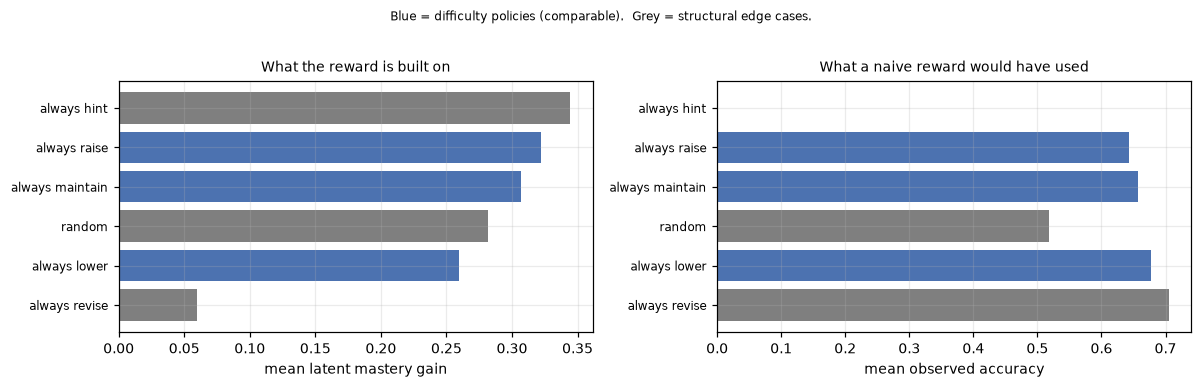

Difficulty policies by OBSERVED ACCURACY:
   always lower  >  always maintain  >  always raise
Difficulty policies by LATENT MASTERY:
   always raise  >  always maintain  >  always lower

RESULT: the two orderings are exactly inverted.
  Making the work easier maximises observed accuracy - the signal a
  naive reward would have optimised - while minimising real learning.
  This is the reward-hacking failure mode, measured on the fitted
  simulator rather than asserted.

'always lower' ranks 3 of 6 by return (0.2391).
  It is NOT the optimal policy, so the latent-mastery reward cannot be
  gamed by simply making the work easier. This is the check that had to
  pass before training an agent.

Best fixed policy by return : always raise (0.3009)
Random baseline             : 0.2004
A state-dependent policy should beat every fixed policy by acting
differently in different states. That gap is the headroom RQ1 depends on.


In [19]:
# The meaningful comparison is between the three DIFFICULTY policies. The other
# two are structural edge cases, shown for completeness only:
#   always hint   - observed accuracy is 0.000 by construction, because a hint
#                   forces the item to be recorded incorrect.
#   always revise - its observed record comes from the PREREQUISITE skill rather
#                   than the target, so the accuracy is not comparable.
DIFFICULTY_POLICIES = ["always lower", "always maintain", "always raise"]

order = comparison.index
colours = [BLUE if p in DIFFICULTY_POLICIES else GREY for p in order]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.4))
a1.barh(range(len(order)), comparison["mastery_gain"], color=colours)
a1.set_yticks(range(len(order)))
a1.set_yticklabels(order, fontsize=8)
a1.set_xlabel("mean latent mastery gain")
a1.set_title("What the reward is built on", fontsize=9)
a1.invert_yaxis()

a2.barh(range(len(order)), comparison["observed_accuracy"], color=colours)
a2.set_yticks(range(len(order)))
a2.set_yticklabels(order, fontsize=8)
a2.set_xlabel("mean observed accuracy")
a2.set_title("What a naive reward would have used", fontsize=9)
a2.invert_yaxis()

fig.suptitle("Blue = difficulty policies (comparable).  Grey = structural edge cases.",
             fontsize=8, y=1.02)
fig.tight_layout()
fig.savefig(FIGURES / "fig_4_13_reward_hacking_test.png", bbox_inches="tight")
plt.show()

# ---- the verdict ---------------------------------------------------------
d = comparison.loc[DIFFICULTY_POLICIES]
by_accuracy = list(d.sort_values("observed_accuracy", ascending=False).index)
by_mastery = list(d.sort_values("mastery_gain", ascending=False).index)
inverted = by_accuracy == by_mastery[::-1]

ranked = list(comparison.sort_values("return", ascending=False).index)
lower_rank = ranked.index("always lower") + 1

print("Difficulty policies by OBSERVED ACCURACY:")
print("   " + "  >  ".join(by_accuracy))
print("Difficulty policies by LATENT MASTERY:")
print("   " + "  >  ".join(by_mastery))
print()

if inverted:
    print("RESULT: the two orderings are exactly inverted.")
    print("  Making the work easier maximises observed accuracy - the signal a")
    print("  naive reward would have optimised - while minimising real learning.")
    print("  This is the reward-hacking failure mode, measured on the fitted")
    print("  simulator rather than asserted.")
else:
    print("RESULT: not a clean inversion. Report the orderings as they are.")

print()
print(f"'always lower' ranks {lower_rank} of {len(ranked)} by return "
      f"({comparison.loc['always lower', 'return']:.4f}).")
if lower_rank > 1:
    print("  It is NOT the optimal policy, so the latent-mastery reward cannot be")
    print("  gamed by simply making the work easier. This is the check that had to")
    print("  pass before training an agent.")
else:
    print("  WARNING: lowering difficulty is optimal. The reward is still hackable.")
    print("  Fix the environment before training anything.")

best = ranked[0]
print()
print(f"Best fixed policy by return : {best} ({comparison.loc[best, 'return']:.4f})")
print(f"Random baseline             : {comparison.loc['random', 'return']:.4f}")
print("A state-dependent policy should beat every fixed policy by acting")
print("differently in different states. That gap is the headroom RQ1 depends on.")

Only the three difficulty policies (blue) are directly comparable. `always hint` has an observed accuracy of 0 because hinted items are recorded as incorrect, and `always revise` reports accuracy on the prerequisite skill.

For the difficulty policies, the order on observed accuracy is the reverse of the order on mastery gain: always lowering difficulty gives the highest accuracy and the lowest mastery gain.